# Probability Distributions in AI/ML - Practice Notebook

This notebook contains conceptual and coding questions on Normal, Binomial, and Poisson distributions.

---

## 1. Normal Distribution

**Q1:** Generate a normal distribution with mean=0 and std=1. Plot it.

**Q2:** Simulate exam scores of 1000 students assuming normal distribution. What percentage scored above 85?

**Q3 (Thinking):** How does changing standard deviation affect the spread? Visualize.

In [1]:
# Your code here
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)  
print("Libraries ready!")

Libraries ready!


In [2]:
mu    = 0   
sigma = 1   

#  normal distribution object
normal = stats.norm(loc=mu, scale=sigma)

print(f"Mean = {normal.mean()}")  
print(f"Std  = {normal.std()}")    

Mean = 0.0
Std  = 1.0


In [3]:
# 1000 values generate
samples = normal.rvs(1000)


print(f"Generated samples : {len(samples)}")
print(f"Sample mean       : {samples.mean():.4f}")  
print(f"Sample std        : {samples.std():.4f}")

Generated samples : 1000
Sample mean       : 0.0193
Sample std        : 0.9787


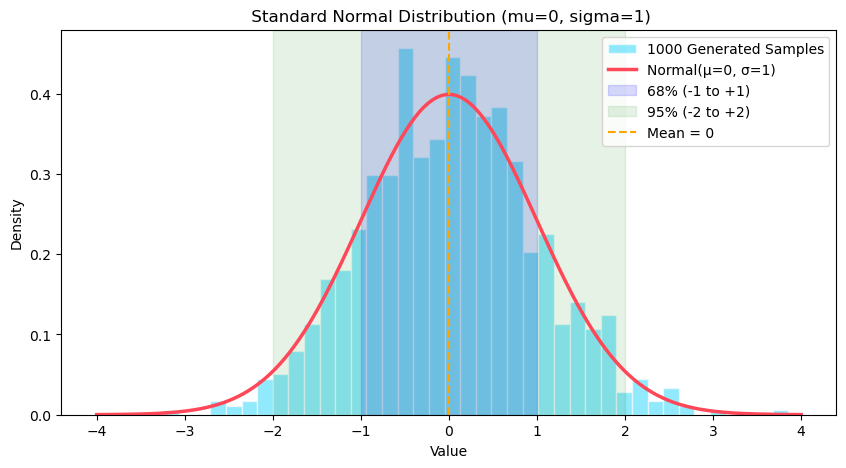

In [ ]:
plt.figure(figsize=(10, 5))

# Histogram — actual generated data
plt.hist(samples, bins=40,
         density=True,
         color='#48dbfb',
         alpha=0.6,
         edgecolor='white',
         label='1000 Generated Samples')

# Smooth curve — theoretical normal
x = np.linspace(-4, 4, 300)
plt.plot(x, normal.pdf(x),
         color='#ff4757',
         linewidth=2.5,
         label='Normal(mu=0, sigma=1)')

# 3 zones shade 
plt.axvspan(-1, 1, alpha=0.15, color='blue',  label='68% (-1 to +1)')
plt.axvspan(-2, 2, alpha=0.10, color='green', label='95% (-2 to +2)')
plt.axvline(0, color='orange', linestyle='--',
            linewidth=1.5, label='Mean = 0')

plt.title(' Standard Normal Distribution (mu=0, sigma=1)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

In [6]:
# how many samples -1 to +1 
within_1 = np.sum((samples >= -1) & (samples <= 1))
within_2 = np.sum((samples >= -2) & (samples <= 2))
within_3 = np.sum((samples >= -3) & (samples <= 3))

print(f"Within ±1sigma : {within_1/10:.1f}%  (theory: 68%)")
print(f"Within ±2sigma : {within_2/10:.1f}%  (theory: 95%)")
print(f"Within ±3sigma : {within_3/10:.1f}%  (theory: 99.7%)")

Within ±1sigma : 69.8%  (theory: 68%)
Within ±2sigma : 95.9%  (theory: 95%)
Within ±3sigma : 99.7%  (theory: 99.7%)


In [7]:
# Q2 — "Simulate exam scores of 1000 students. What percentage scored above 85?"

mu_exam    = 70   # average score 70
sigma_exam = 10 

In [8]:
exam_dist   = stats.norm(loc=mu_exam, scale=sigma_exam)
exam_scores = exam_dist.rvs(1000)

print(exam_scores[:10])

[83.99355437 79.24633683 70.5963037  63.53063222 76.98223314 73.93485385
 78.9519322  76.35171802 80.49552715 64.64764788]


In [10]:
# By Simulation  count
upar_85       = np.sum(exam_scores > 85)
percentage    = upar_85 / 1000 * 100
print(f"By Simulation  : {percentage:.1f}%")

# By Theory calculate
theory = (1 - exam_dist.cdf(85)) * 100

print(f"By Theory      : {theory:.1f}%")


By Simulation  : 8.0%
By Theory      : 6.7%


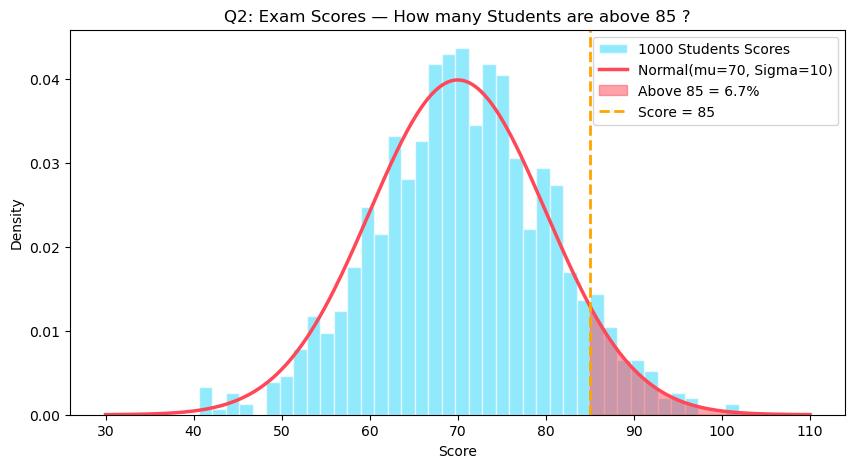

In [11]:
plt.figure(figsize=(10, 5))

# Histogram
plt.hist(exam_scores, bins=40,
         density=True,
         color='#48dbfb', alpha=0.6,
         edgecolor='white',
         label='1000 Students Scores')

# Bell curve
x = np.linspace(30, 110, 300)
plt.plot(x, exam_dist.pdf(x),
         color='#ff4757', linewidth=2.5,
         label=f'Normal(mu={mu_exam}, Sigma={sigma_exam})')

# score more then 85 is  RED
x_above = np.linspace(85, 110, 200)
plt.fill_between(x_above,
                 exam_dist.pdf(x_above),
                 alpha=0.5,
                 color='#ff4757',
                 label=f'Above 85 = {theory:.1f}%')

# 85 se UPAR ek vertical line
plt.axvline(85, color='orange',
            linestyle='--', linewidth=2,
            label='Score = 85')

plt.title('Q2: Exam Scores — How many Students are above 85 ?')
plt.xlabel('Score')
plt.ylabel('Density')
plt.legend()
plt.show()

In [13]:
# Q3 — "How does changing standard deviation affect the spread? Visualize.
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

x = np.linspace(-60, 60, 500)


sigmas = [2, 5, 10, 20]


colors = ['#ff4757', '#48dbfb', '#1dd1a1', '#feca57']



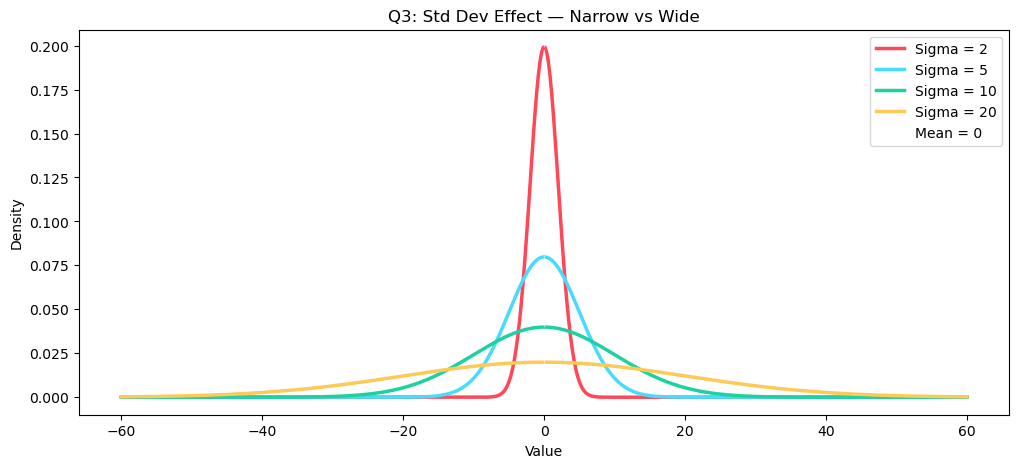

In [14]:
plt.figure(figsize=(12, 5))

for sigma, color in zip(sigmas, colors):
    dist = stats.norm(loc=0, scale=sigma)
    plt.plot(x, dist.pdf(x),
             color=color,
             linewidth=2.5,
             label=f'Sigma = {sigma}')

plt.axvline(0, color='white',
            linestyle='--',
            linewidth=1,
            alpha=0.5,
            label='Mean = 0')

plt.title('Q3: Std Dev Effect — Narrow vs Wide')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

## 2. Binomial Distribution

**Q4:** Simulate 100 coin toss experiments with probability p=0.5. Plot distribution.

**Q5:** Model a scenario where a student guesses MCQs (4 options). What is probability of getting exactly 6 correct out of 10?

**Q6 (Thinking):** When does binomial start resembling normal distribution? Demonstrate.

In [15]:
# Your code here
# Q4 — "Simulate 100 coin toss experiments with p=0.5. Plot distribution.
n = 100   
p = 0.5

In [16]:
from scipy import stats

binom = stats.binom(n, p)

print(f"Mean     = {binom.mean()}")   
print(f"Std Dev  = {binom.std():.2f}") 

Mean     = 50.0
Std Dev  = 5.00


In [17]:
# 1000 time 100 coin toss 
simulations = binom.rvs(1000)

print(f"Min heads : {simulations.min()}")  
print(f"Max heads : {simulations.max()}")  
print(f"Avg heads : {simulations.mean():.1f}")  

Min heads : 36
Max heads : 67
Avg heads : 50.0


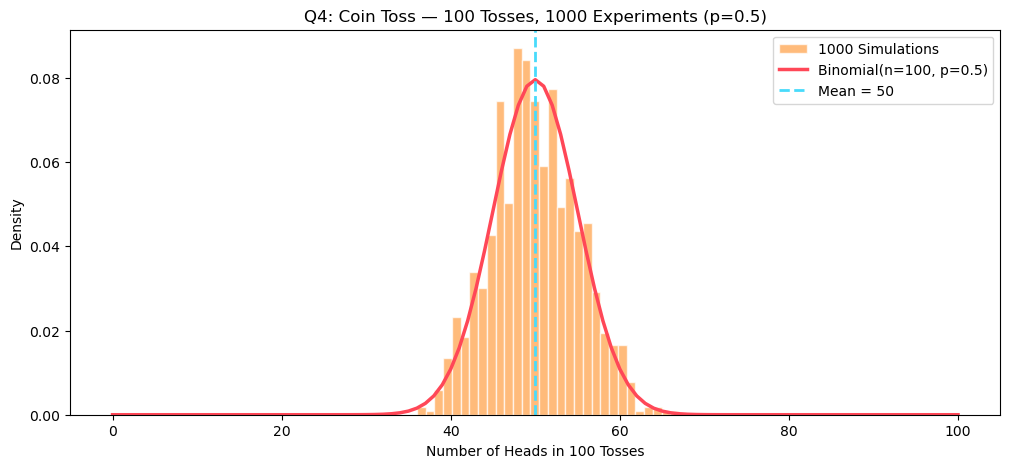

In [19]:

plt.figure(figsize=(12, 5))

# Simulation — histogram
plt.hist(simulations, bins=30,
         density=True,
         color='#ff9f43', alpha=0.7,
         edgecolor='white',
         label='1000 Simulations')

# Theory — smooth curve
k = np.arange(0, n+1)
plt.plot(k, binom.pmf(k),
         color='#ff4757',
         linewidth=2.5,
         label=f'Binomial(n={n}, p={p})')

# Mean line
plt.axvline(binom.mean(),
            color='#48dbfb',
            linestyle='--',
            linewidth=2,
            label=f'Mean = {binom.mean():.0f}')

plt.title(f'Q4: Coin Toss — 100 Tosses, 1000 Experiments (p={p})')
plt.xlabel('Number of Heads in 100 Tosses')
plt.ylabel('Density')
plt.legend()
plt.show()

In [20]:
# Q5 — "Student guesses MCQs (4 options). Probability of exactly 6 correct out of 10?
n = 10    # 10 questions
p = 0.25  # 1/4 = 0.25 
k = 6 



P(exactly 6 sahi) = 0.0162 = 1.62%
P(6 ya zyada sahi) = 0.0197 = 1.97%
P(6 se kam sahi)   = 0.9803 = 98.03%

Mean  = nxp = 2.5 questions expected sahi


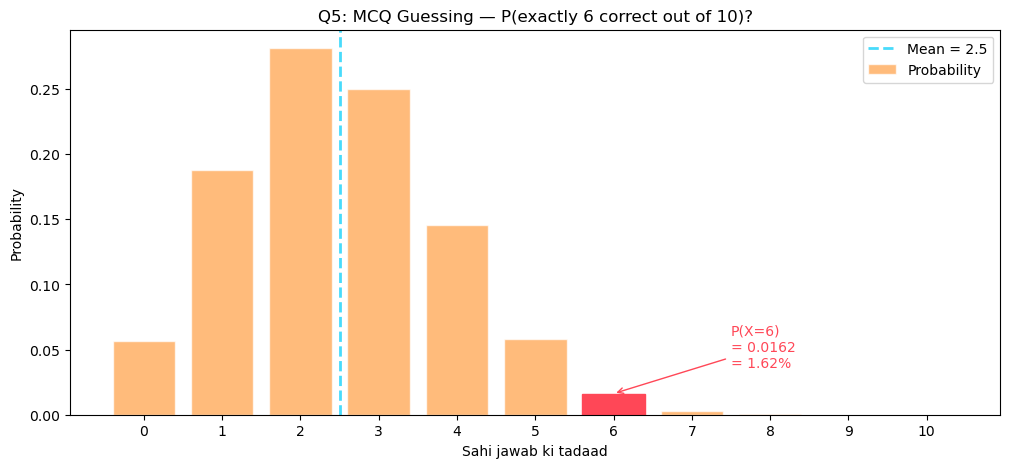

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

#Parameters 
n = 10  
p = 0.25 
k = 6     

# Binomial object 
binom = stats.binom(n, p)

# Probabilities 
p_exactly_6 = binom.pmf(6)
p_atleast_6 = 1 - binom.cdf(5)
p_less_6    = binom.cdf(5)

print(f"P(exactly 6 sahi) = {p_exactly_6:.4f} = {p_exactly_6*100:.2f}%")
print(f"P(6 ya zyada sahi) = {p_atleast_6:.4f} = {p_atleast_6*100:.2f}%")
print(f"P(6 se kam sahi)   = {p_less_6:.4f} = {p_less_6*100:.2f}%")
print(f"\nMean  = nxp = {binom.mean():.1f} questions expected sahi")

# Plot
plt.figure(figsize=(12, 5))

k_values = np.arange(0, n+1)
probs    = binom.pmf(k_values)

bars = plt.bar(k_values, probs,
               color='#ff9f43',
               alpha=0.7,
               edgecolor='white',
               label='Probability')

# Exactly 6 
bars[6].set_color('#ff4757')
bars[6].set_alpha(1.0)

# Annotation
plt.annotate(f'P(X=6)\n= {p_exactly_6:.4f}\n= {p_exactly_6*100:.2f}%',
             xy=(6, p_exactly_6),
             xytext=(7.5, p_exactly_6+0.02),
             fontsize=10,
             color='#ff4757',
             arrowprops=dict(arrowstyle='->',
                           color='#ff4757'))

plt.axvline(binom.mean(),
            color='#48dbfb',
            linestyle='--',
            linewidth=2,
            label=f'Mean = {binom.mean():.1f}')

plt.title('Q5: MCQ Guessing — P(exactly 6 correct out of 10)?')
plt.xlabel('Sahi jawab ki tadaad')
plt.ylabel('Probability')
plt.xticks(k_values)
plt.legend()
plt.show()

In [22]:
# Q6 — "When does Binomial start resembling Normal distribution? Demonstrate.

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

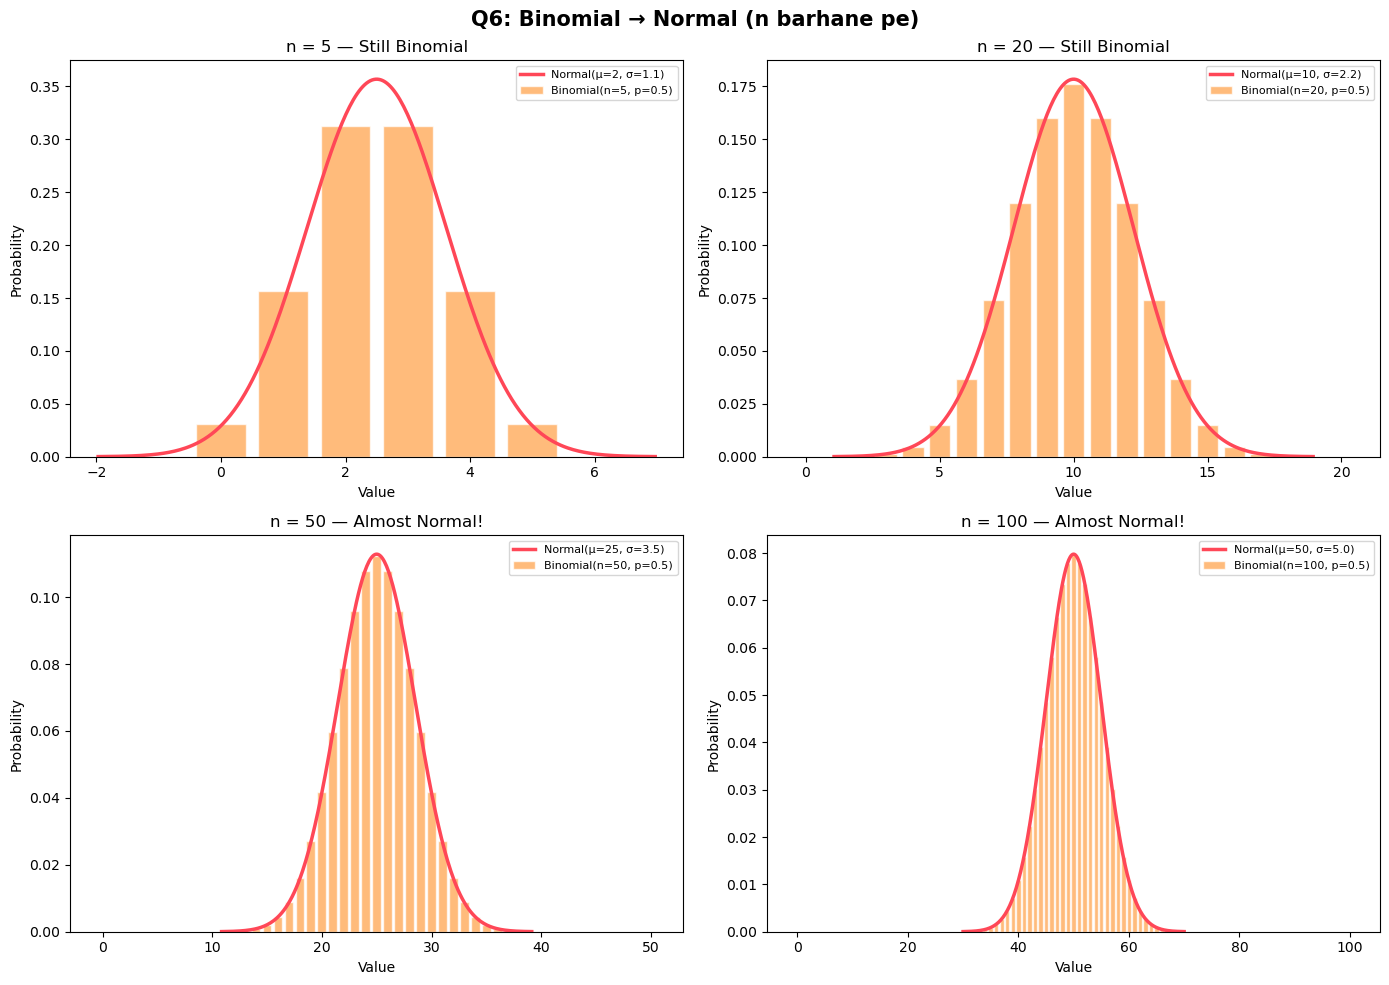

In [23]:

# for different n values 
n_values = [5, 20, 50, 100]
p        = 0.5
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes      = axes.flatten()

for i, n in enumerate(n_values):

    # Binomial
    binom  = stats.binom(n, p)
    k_vals = np.arange(0, n+1)
    probs  = binom.pmf(k_vals)

    # Normal — same mean and std
    mu_n   = n * p
    sig_n  = np.sqrt(n * p * (1-p))
    normal = stats.norm(mu_n, sig_n)

    ax = axes[i]

    # Binomial bars
    ax.bar(k_vals, probs,
           color='#ff9f43', alpha=0.7,
           edgecolor='white',
           label=f'Binomial(n={n}, p={p})')

    # Normal curve
    x = np.linspace(mu_n - 4*sig_n,
                    mu_n + 4*sig_n, 300)
    ax.plot(x, normal.pdf(x),
            color='#ff4757',
            linewidth=2.5,
            label=f'Normal(μ={mu_n:.0f}, σ={sig_n:.1f})')

    ax.set_title(f'n = {n} — {"Almost Normal!" if n>=30 else "Still Binomial"}',
                 fontsize=12)
    ax.set_xlabel('Value')
    ax.set_ylabel('Probability')
    ax.legend(fontsize=8)

plt.suptitle('Q6: Binomial → Normal (n barhane pe)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()



In [24]:
# ─── Print results ────────────────────────────────────
print("Result on different N values:")
print(f"n=5   → Binomial and Normal have large different ")
print(f"n=20  → less different ")
print(f"n=50  → similar")
print(f"n=100 → Same as Normal  ✅")
print(f"\nRule: n >= 30 then Binomial ≈ Normal!")

Result on different N values:
n=5   → Binomial and Normal have large different 
n=20  → less different 
n=50  → similar
n=100 → Same as Normal  ✅

Rule: n >= 30 then Binomial ≈ Normal!


## 3. Poisson Distribution

**Q7:** Model number of calls received per minute in a call center (lambda=5).

**Q8:** What is probability of receiving exactly 3 calls in a minute?

**Q9 (Thinking):** When should Poisson be used instead of Binomial? Simulate example.

In [1]:
# Your code here
#Q7 — "Model number of calls received per minute in a call center (lambda=5)"
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

lam = 5   # average 5 calls per minute

#  Poisson object
poisson = stats.poisson(lam)

print(f"Lambda (λ)   = {lam}")
print(f"Mean         = {poisson.mean()}")   
print(f"Variance     = {poisson.var()}")    
print(f"Std Dev      = {poisson.std():.2f}") 


Lambda (λ)   = 5
Mean         = 5.0
Variance     = 5.0
Std Dev      = 2.24


In [2]:
# Probabilities 
print(f"\nP(exactly 5 calls) = {poisson.pmf(5):.4f}")
print(f"P(0 calls)         = {poisson.pmf(0):.4f}")
print(f"P(10+ calls)       = {1-poisson.cdf(9):.4f}")


P(exactly 5 calls) = 0.1755
P(0 calls)         = 0.0067
P(10+ calls)       = 0.0318


In [3]:
#1000 minutes simulate 
simulations = poisson.rvs(1000)
print(f"\nSimulated avg calls = {simulations.mean():.2f}")


Simulated avg calls = 4.99


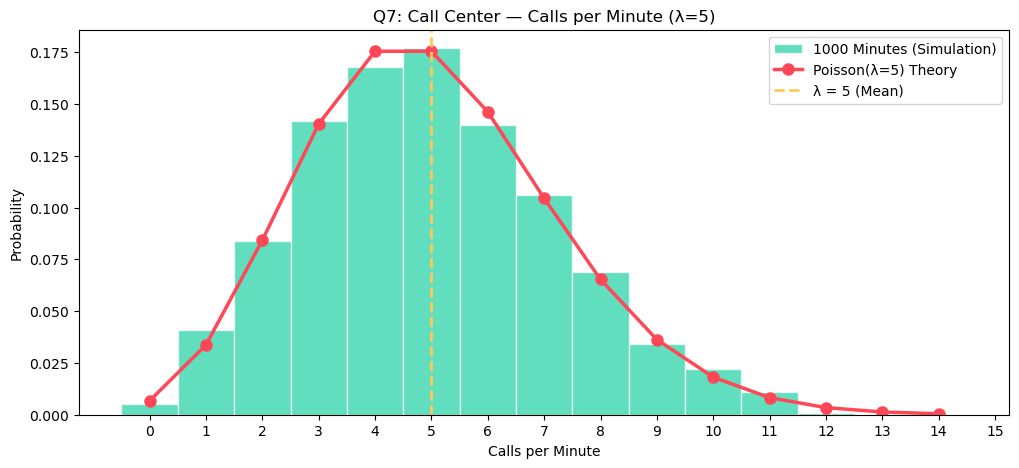

In [4]:
plt.figure(figsize=(12, 5))

# Simulation — histogram
plt.hist(simulations, bins=range(0, 16),
         density=True,
         color='#1dd1a1', alpha=0.7,
         edgecolor='white',
         label='1000 Minutes (Simulation)',
         align='left')
# Theory — PMF dots
k_vals = np.arange(0, 15)
plt.plot(k_vals, poisson.pmf(k_vals),
         'o-', color='#ff4757',
         linewidth=2.5, markersize=8,
         label=f'Poisson(λ={lam}) Theory')

# Lambda line
plt.axvline(lam,
            color='#feca57',
            linestyle='--',
            linewidth=2,
            label=f'λ = {lam} (Mean)')
plt.title(f'Q7: Call Center — Calls per Minute (λ={lam})')
plt.xlabel('Calls per Minute')
plt.ylabel('Probability')
plt.xticks(range(0, 16))
plt.legend()
plt.show()

In [5]:
# Q8 — "What is probability of receiving exactly 3 calls in a minute?"#
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

lam = 5  
poisson = stats.poisson(lam)

In [6]:
# Calculate Exactly 3 calls probability
p_exactly_3 = poisson.pmf(3)
p_less_3    = poisson.cdf(2)
p_atleast_3 = 1 - poisson.cdf(2)

print(f"P(exactly 3 calls) = {p_exactly_3:.4f} = {p_exactly_3*100:.2f}%")
print(f"P(less than 3)     = {p_less_3:.4f} = {p_less_3*100:.2f}%")
print(f"P(3 ya zyada)      = {p_atleast_3:.4f} = {p_atleast_3*100:.2f}%")

P(exactly 3 calls) = 0.1404 = 14.04%
P(less than 3)     = 0.1247 = 12.47%
P(3 ya zyada)      = 0.8753 = 87.53%


In [8]:
# compare all probabilities 
print(f"\nALL 10  probabilities:")
for k in range(11):
    bar = '█' * int(poisson.pmf(k) * 100)
    print(f"P(X={k:2d}) = {poisson.pmf(k):.4f}  {bar}")


ALL 10  probabilities:
P(X= 0) = 0.0067  
P(X= 1) = 0.0337  ███
P(X= 2) = 0.0842  ████████
P(X= 3) = 0.1404  ██████████████
P(X= 4) = 0.1755  █████████████████
P(X= 5) = 0.1755  █████████████████
P(X= 6) = 0.1462  ██████████████
P(X= 7) = 0.1044  ██████████
P(X= 8) = 0.0653  ██████
P(X= 9) = 0.0363  ███
P(X=10) = 0.0181  █


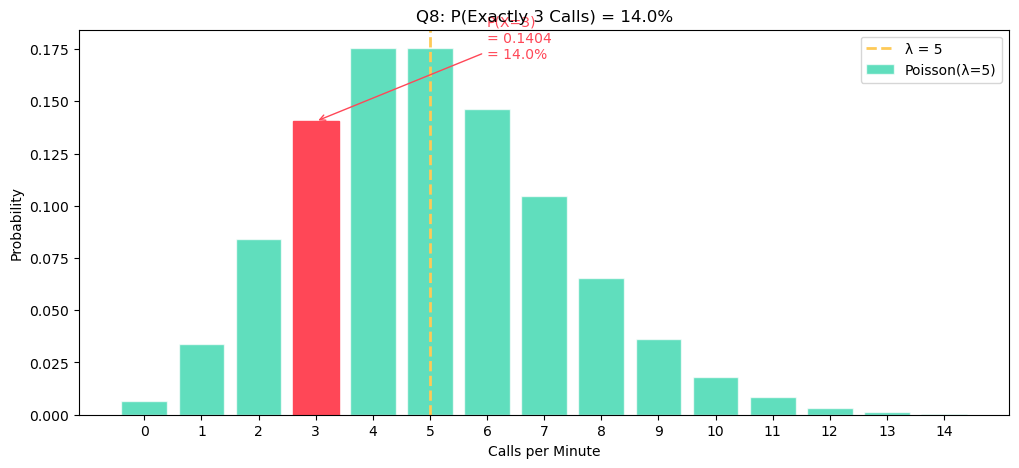

In [ ]:
plt.figure(figsize=(12, 5))

k_vals = np.arange(0, 15)
probs  = poisson.pmf(k_vals)

# All bars
bars = plt.bar(k_vals, probs,
               color='#1dd1a1',
               alpha=0.7,
               edgecolor='white',
               label='Poisson(λ=5)')

# Exactly 3 highlight 
bars[3].set_color('#ff4757')
bars[3].set_alpha(1.0)

# Annotation
plt.annotate(
    f'P(X=3)\n= {p_exactly_3:.4f}\n= {p_exactly_3*100:.1f}%',
    xy=(3, p_exactly_3),
    xytext=(6, p_exactly_3 + 0.03),
    fontsize=10,
    color='#ff4757',
    arrowprops=dict(arrowstyle='->',
                    color='#ff4757'))

# Lambda line
plt.axvline(lam,
            color='#feca57',
            linestyle='--',
            linewidth=2,
            label=f'λ = {lam}')

plt.title(f'Q8: P(Exactly 3 Calls) = {p_exactly_3*100:.1f}%')
plt.xlabel('Calls per Minute')
plt.ylabel('Probability')
plt.xticks(k_vals)
plt.legend()
plt.show()

In [10]:
#  Q9 — "When should Poisson be used instead of Binomial? Simulate example.
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# ─── Case 1: Binomial vs Poisson compare ──────────────
# n is large, p ia small, n*p = lambda
n   = 1000
p   = 0.005
lam = n * p     

binom   = stats.binom(n, p)
poisson = stats.poisson(lam)

print("─── Binomial vs Poisson ───")
print(f"Binomial(n={n}, p={p})")
print(f"Poisson (λ={lam})")
print(f"\nBinomial Mean = {binom.mean():.2f}")
print(f"Poisson  Mean = {poisson.mean():.2f}")
print(f"\nBinomial Var  = {binom.var():.4f}")
print(f"Poisson  Var  = {poisson.var():.4f}")


─── Binomial vs Poisson ───
Binomial(n=1000, p=0.005)
Poisson (λ=5.0)

Binomial Mean = 5.00
Poisson  Mean = 5.00

Binomial Var  = 4.9750
Poisson  Var  = 5.0000


C:\Users\Mani\AppData\Local\Temp\ipykernel_6384\3539146765.py:64: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


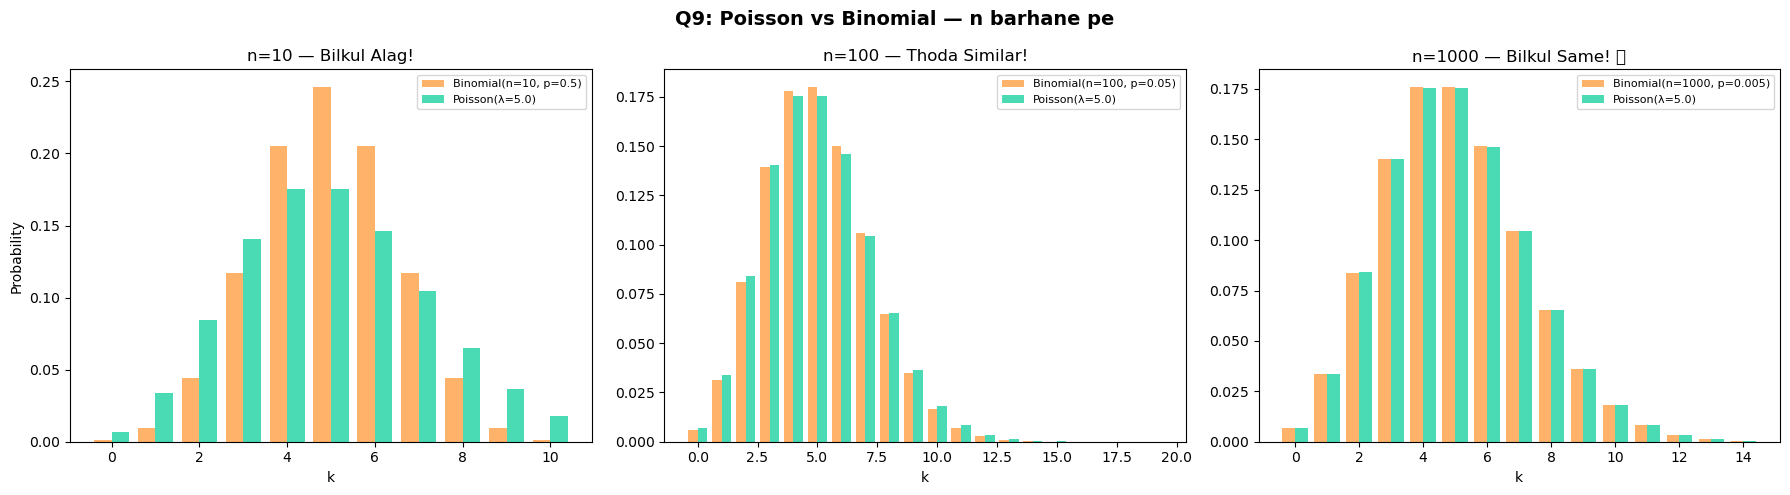


─── Kab Kaunsa Use Karein ───
Binomial → n fix, p is given, n is small
Poisson  → n large, p small, sirf λ is given
Both same → n>=1000, p<=0.01, n*p=λ


In [12]:

# Plot 1: Binomial vs Poisson 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subplot 1: n is Small 
n1, p1   = 10, 0.5
lam1     = n1 * p1
binom1   = stats.binom(n1, p1)
poisson1 = stats.poisson(lam1)
k1       = np.arange(0, n1+1)

axes[0].bar(k1 - 0.2, binom1.pmf(k1),
            width=0.4,
            color='#ff9f43', alpha=0.8,
            label=f'Binomial(n={n1}, p={p1})')
axes[0].bar(k1 + 0.2, poisson1.pmf(k1),
            width=0.4,
            color='#1dd1a1', alpha=0.8,
            label=f'Poisson(λ={lam1})')
axes[0].set_title('n=10 — Bilkul Alag!')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Probability')
axes[0].legend(fontsize=8)

# Subplot 2: n is Medium 
n2, p2   = 100, 0.05
lam2     = n2 * p2
binom2   = stats.binom(n2, p2)
poisson2 = stats.poisson(lam2)
k2       = np.arange(0, 20)

axes[1].bar(k2 - 0.2, binom2.pmf(k2),
            width=0.4,
            color='#ff9f43', alpha=0.8,
            label=f'Binomial(n={n2}, p={p2})')
axes[1].bar(k2 + 0.2, poisson2.pmf(k2),
            width=0.4,
            color='#1dd1a1', alpha=0.8,
            label=f'Poisson(λ={lam2})')
axes[1].set_title('n=100 — Thoda Similar!')
axes[1].set_xlabel('k')
axes[1].legend(fontsize=8)

# Subplot 3: n is large 
n3, p3   = 1000, 0.005
lam3     = n3 * p3
binom3   = stats.binom(n3, p3)
poisson3 = stats.poisson(lam3)
k3       = np.arange(0, 15)

axes[2].bar(k3 - 0.2, binom3.pmf(k3),
            width=0.4,
            color='#ff9f43', alpha=0.8,
            label=f'Binomial(n={n3}, p={p3})')
axes[2].bar(k3 + 0.2, poisson3.pmf(k3),
            width=0.4,
            color='#1dd1a1', alpha=0.8,
            label=f'Poisson(λ={lam3})')
axes[2].set_title('n=1000 — Bilkul Same! ✅')
axes[2].set_xlabel('k')
axes[2].legend(fontsize=8)

plt.suptitle('Q9: Poisson vs Binomial — n barhane pe',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# When Poisson use karein 
print("\n─── Kab Kaunsa Use Karein ───")
print("Binomial → n fix, p is given, n is small")
print("Poisson  → n large, p small, sirf λ is given")
print("Both same → n>=1000, p<=0.01, n*p=λ")


## 4. Real-world Modeling + Pipeline

**Q10:** Create synthetic dataset where target follows a distribution.

**Q11:** Build a pipeline using sklearn that:
- Generates features
- Scales data
- Fits a model

**Q12 (Challenge):** Identify which distribution best fits given dataset.

In [13]:
# Your code here
# Q10 — "Create synthetic dataset where target follows a distribution.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# create Features (X) ───────────────────────
n_samples = 1000   # 1000 house

# Feature 1: Size (500 to 3000 sqft)
size = np.random.uniform(500, 3000, n_samples)

# Feature 2: Rooms (1 to 6)
rooms = np.random.randint(1, 7, n_samples)

# Feature 3: Age (0 to 50 years)
age = np.random.uniform(0, 50, n_samples)

# create Target (y)
noise = np.random.normal(0, 10000, n_samples)
price = (size * 100) + (rooms * 20000) - (age * 500) + noise

# create  DataFrame 
df = pd.DataFrame({
    'Size'  : size,
    'Rooms' : rooms,
    'Age'   : age,
    'Price' : price
})

print("─── Dataset Info ───")
print(f"Shape  : {df.shape}")
print(f"\n{df.head()}")
print(f"\n─── Price Stats ───")
print(f"Mean   : {df['Price'].mean():,.0f}")
print(f"Std    : {df['Price'].std():,.0f}")
print(f"Min    : {df['Price'].min():,.0f}")
print(f"Max    : {df['Price'].max():,.0f}")

─── Dataset Info ───
Shape  : (1000, 4)

          Size  Rooms        Age          Price
0  1436.350297      4  22.360127  208749.060968
1  2876.785766      6  30.029717  413701.779190
2  2329.984855      3  25.783971  277376.302153
3  1996.646210      5  45.969599  280331.075839
4   890.046601      1  24.848174  106289.986352

─── Price Stats ───
Mean   : 229,786
Std    : 82,735
Min    : 50,394
Max    : 420,056


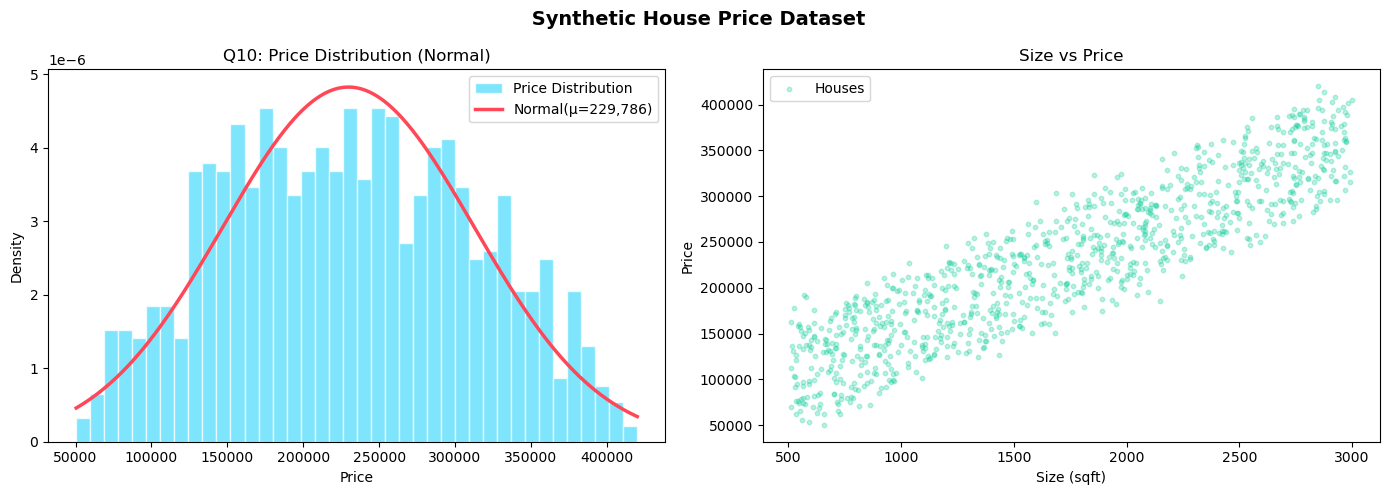

In [14]:
# Plot 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Price distribution
axes[0].hist(df['Price'], bins=40,
             density=True,
             color='#48dbfb', alpha=0.7,
             edgecolor='white',
             label='Price Distribution')

# Normal curve fit 
mu, sigma = stats.norm.fit(df['Price'])
x = np.linspace(df['Price'].min(),
                df['Price'].max(), 300)
axes[0].plot(x, stats.norm.pdf(x, mu, sigma),
             color='#ff4757', linewidth=2.5,
             label=f'Normal(μ={mu:,.0f})')
axes[0].set_title('Q10: Price Distribution (Normal)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Density')
axes[0].legend()

# Plot 2: Size vs Price scatter
axes[1].scatter(df['Size'], df['Price'],
                color='#1dd1a1', alpha=0.3,
                s=10, label='Houses')
axes[1].set_title('Size vs Price')
axes[1].set_xlabel('Size (sqft)')
axes[1].set_ylabel('Price')
axes[1].legend()

plt.suptitle(' Synthetic House Price Dataset',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [15]:
# Q11 — "Build a pipeline using sklearn that generates features, scales data, fits a model."

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

np.random.seed(42)

In [16]:
# Use Q10  data 
n_samples = 1000

size  = np.random.uniform(500, 3000, n_samples)
rooms = np.random.randint(1, 7, n_samples)
age   = np.random.uniform(0, 50, n_samples)
noise = np.random.normal(0, 10000, n_samples)
price = (size*100) + (rooms*20000) - (age*500) + noise

# split the data into features and target
X = np.column_stack([size, rooms, age])
y = price

print(f"X shape : {X.shape}")   # (1000, 3)
print(f"y shape : {y.shape}")   # (1000,)

# Train Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    
    random_state=42
)

print(f"\nTrain size : {X_train.shape[0]}")  
print(f"Test size  : {X_test.shape[0]}")     

X shape : (1000, 3)
y shape : (1000,)

Train size : 800
Test size  : 200


In [17]:
# create Pipeline banao 
pipeline = Pipeline([
    ('scaler', StandardScaler()),       
    ('model',  LinearRegression())      
])

# Train Model
pipeline.fit(X_train, y_train)
print("\nPipeline trained! ✅")


Pipeline trained! ✅


In [18]:
# Predict 
y_pred = pipeline.predict(X_test)

In [19]:
# Find Score 
r2  = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"\n─── Model Results ───")
print(f"R2 Score : {r2:.4f}")  
print(f"RMSE     : {rmse:,.0f}")


─── Model Results ───
R2 Score : 0.9855
RMSE     : 9,501


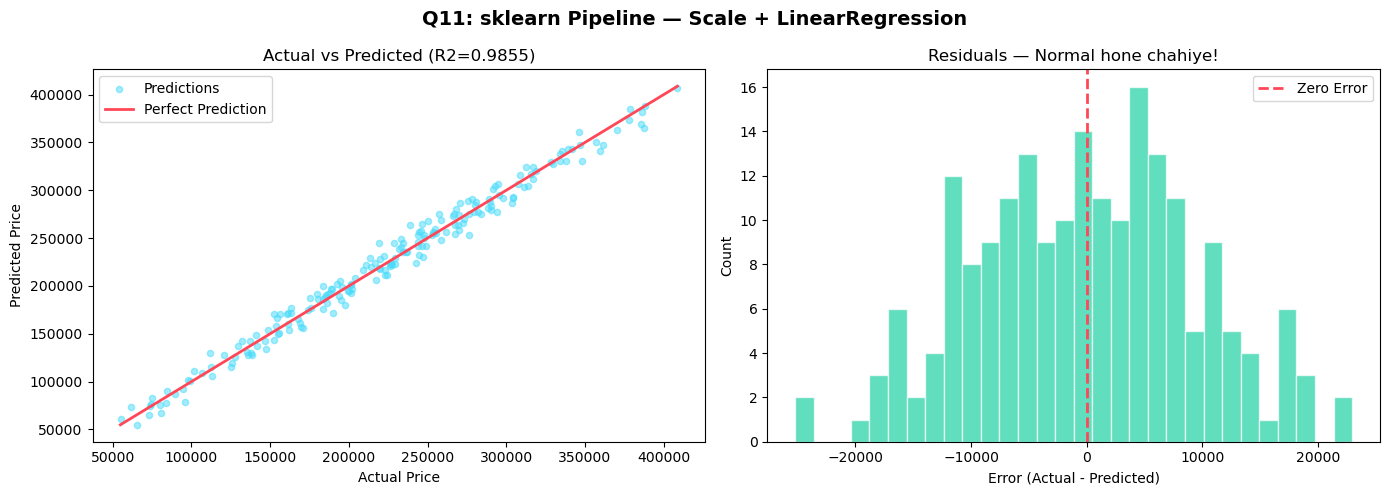

In [20]:

  

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred,
                color='#48dbfb',
                alpha=0.5, s=20,
                label='Predictions')

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val],
             [min_val, max_val],
             color='#ff4757',
             linewidth=2,
             label='Perfect Prediction')

axes[0].set_title(f'Actual vs Predicted (R2={r2:.4f})')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].legend()

# Plot 2: Residuals
residuals = y_test - y_pred
axes[1].hist(residuals, bins=30,
             color='#1dd1a1',
             alpha=0.7,
             edgecolor='white')
axes[1].axvline(0, color='#ff4757',
                linestyle='--',
                linewidth=2,
                label='Zero Error')
axes[1].set_title('Residuals — Normal hone chahiye!')
axes[1].set_xlabel('Error (Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Q11: sklearn Pipeline — Scale + LinearRegression',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
# Your code here
#Q12 — "Identify which distribution best fits given dataset." (Challenge!)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

In [28]:
#  Create different   datasets 
data_normal = stats.norm(loc=50, scale=10).rvs(1000)
data_exp    = stats.expon(scale=20).rvs(1000)
data_pois   = stats.poisson(mu=5).rvs(1000)

datasets = {
    'Dataset A' : data_normal,
    'Dataset B' : data_exp,
    'Dataset C' : data_pois
}

In [29]:
# Function — Find best fit Distribution
def find_best_distribution(data, name):
    print(f"\n{'='*40}")
    print(f"  {name} — Find Best Distribution")
    print(f"{'='*40}")

    # Distributions try 
    distributions = {
        'Normal'      : stats.norm,
        'Exponential' : stats.expon,
        'Poisson'     : stats.poisson
    }

    best_name  = None
    best_score = np.inf  

    for dist_name, dist in distributions.items():
        try:
            # Parameters fit 
            if dist_name == 'Poisson':
                params = (data.mean(),)
                fitted = dist(mu=params[0])
            else:
                params = dist.fit(data)
                fitted = dist(*params)

            # KS Test 
            ks_stat, p_value = stats.kstest(
                data,
                fitted.cdf
            )

            print(f"\n{dist_name}:")
            print(f"  KS Stat  = {ks_stat:.4f}")
            print(f"  P-value  = {p_value:.4f}")
            print(f"  Fit      = {'Good ✅' if p_value > 0.05 else 'Poor ❌'}")

            # Best score track
            if ks_stat < best_score:
                best_score = ks_stat
                best_name  = dist_name

        except Exception as e:
            print(f"{dist_name}: Error — {e}")

    print(f"\nBest Fit: {best_name} ✅")
    return best_name


In [30]:
# Check on every dataset 
results = {}
for name, data in datasets.items():
    best = find_best_distribution(data, name)
    results[name] = best


  Dataset A — Find Best Distribution

Normal:
  KS Stat  = 0.0215
  P-value  = 0.7370
  Fit      = Good ✅

Exponential:
  KS Stat  = 0.3622
  P-value  = 0.0000
  Fit      = Poor ❌

Poisson:
  KS Stat  = 0.0998
  P-value  = 0.0000
  Fit      = Poor ❌

Best Fit: Normal ✅

  Dataset B — Find Best Distribution

Normal:
  KS Stat  = 0.1581
  P-value  = 0.0000
  Fit      = Poor ❌

Exponential:
  KS Stat  = 0.0203
  P-value  = 0.7965
  Fit      = Good ✅

Poisson:
  KS Stat  = 0.4247
  P-value  = 0.0000
  Fit      = Poor ❌

Best Fit: Exponential ✅

  Dataset C — Find Best Distribution

Normal:
  KS Stat  = 0.1225
  P-value  = 0.0000
  Fit      = Poor ❌

Exponential:
  KS Stat  = 0.3379
  P-value  = 0.0000
  Fit      = Poor ❌

Poisson:
  KS Stat  = 0.1980
  P-value  = 0.0000
  Fit      = Poor ❌

Best Fit: Normal ✅


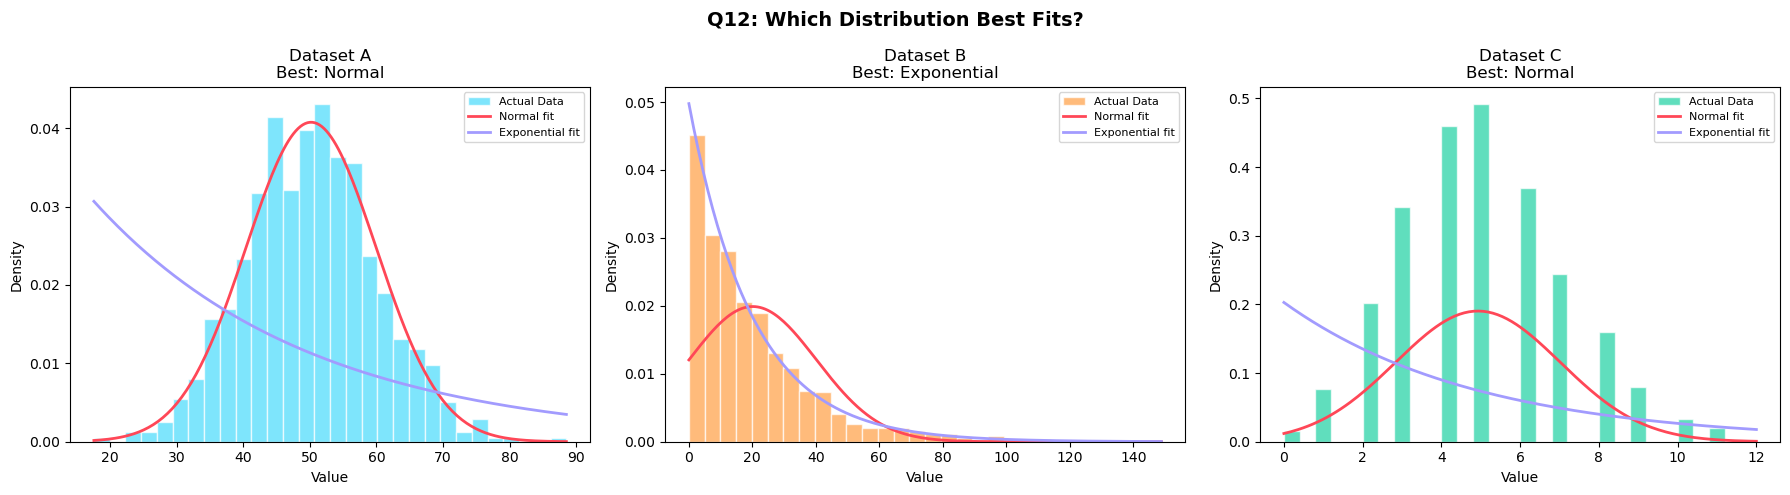


  FINAL RESULTS
Dataset A → Normal
Dataset B → Exponential
Dataset C → Normal


In [31]:
# plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#48dbfb', '#ff9f43', '#1dd1a1']

for i, (name, data) in enumerate(datasets.items()):
    ax = axes[i]

    # Histogram
    ax.hist(data, bins=30, density=True,
            color=colors[i], alpha=0.7,
            edgecolor='white',
            label='Actual Data')

    # Normal curve
    mu, sigma = stats.norm.fit(data)
    x = np.linspace(data.min(), data.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma),
            color='#ff4757', linewidth=2,
            label='Normal fit')

    # Exponential curve
    loc, scale = stats.expon.fit(data)
    ax.plot(x, stats.expon.pdf(x, loc, scale),
            color='#a29bfe', linewidth=2,
            label='Exponential fit')

    ax.set_title(f'{name}\nBest: {results[name]}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Q12: Which Distribution Best Fits?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ─── Step 5: Final Summary ────────────────────────────
print(f"\n{'='*40}")
print("  FINAL RESULTS")
print(f"{'='*40}")
for name, best in results.items():
    print(f"{name} → {best}")

## 🚨 Mini Project: Fraud Detection using Poisson Anomalies

A payment system records number of transactions per minute.

**Q13:** Simulate normal transaction behavior (λ = 5).

**Q14:** Inject anomalies (fraud spikes).

**Q15:** Detect anomalies using Poisson probability threshold.

**Q16 (Thinking):** How would you reduce false positives?


In [32]:
# Q13 — "Simulate normal transaction behavior (λ = 5)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

In [33]:
lam          = 5     
n_minutes    = 200   

# Normal Transactions Simulate 
poisson      = stats.poisson(lam)
transactions = poisson.rvs(n_minutes)

print(f"─── Normal Transaction Stats ───")
print(f"Total Minutes    : {n_minutes}")
print(f"Lambda (λ)       : {lam}")
print(f"Mean Transactions: {transactions.mean():.2f}")
print(f"Std Dev          : {transactions.std():.2f}")
print(f"Min              : {transactions.min()}")
print(f"Max              : {transactions.max()}")

─── Normal Transaction Stats ───
Total Minutes    : 200
Lambda (λ)       : 5
Mean Transactions: 4.96
Std Dev          : 2.23
Min              : 1
Max              : 11


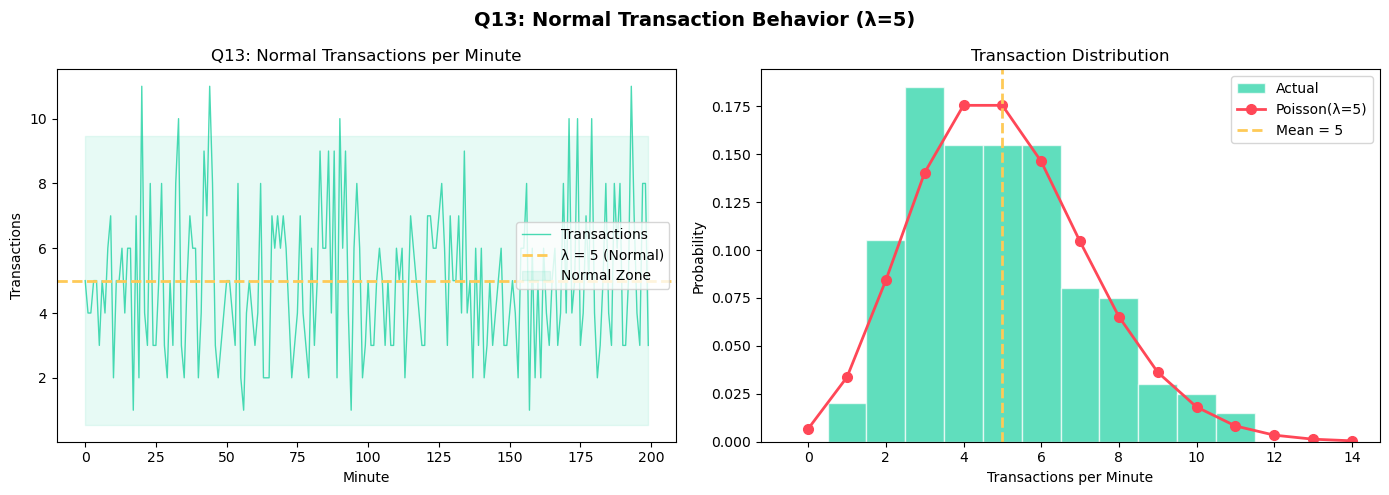

In [34]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Time series — minute by minute
axes[0].plot(range(n_minutes), transactions,
             color='#1dd1a1', linewidth=1,
             alpha=0.8, label='Transactions')
axes[0].axhline(lam, color='#feca57',
                linestyle='--', linewidth=2,
                label=f'λ = {lam} (Normal)')
axes[0].fill_between(range(n_minutes),
                     lam - 2*transactions.std(),
                     lam + 2*transactions.std(),
                     alpha=0.1, color='#1dd1a1',
                     label='Normal Zone')
axes[0].set_title('Q13: Normal Transactions per Minute')
axes[0].set_xlabel('Minute')
axes[0].set_ylabel('Transactions')
axes[0].legend()

# Plot 2: Distribution
axes[1].hist(transactions, bins=range(0, 15),
             density=True,
             color='#1dd1a1', alpha=0.7,
             edgecolor='white',
             label='Actual',
             align='left')

k_vals = np.arange(0, 15)
axes[1].plot(k_vals, poisson.pmf(k_vals),
             'o-', color='#ff4757',
             linewidth=2, markersize=7,
             label=f'Poisson(λ={lam})')

axes[1].axvline(lam, color='#feca57',
                linestyle='--', linewidth=2,
                label=f'Mean = {lam}')

axes[1].set_title('Transaction Distribution')
axes[1].set_xlabel('Transactions per Minute')
axes[1].set_ylabel('Probability')
axes[1].legend()

plt.suptitle('Q13: Normal Transaction Behavior (λ=5)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [1]:
# Q14 — "Inject anomalies (fraud spikes)"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)


In [2]:
# Q13 data reuse
lam       = 5
n_minutes = 200
poisson   = stats.poisson(lam)

# Normal transactions
transactions = poisson.rvs(n_minutes).astype(float)

print(f"Before fraud injection:")
print(f"Mean : {transactions.mean():.2f}")
print(f"Max  : {transactions.max():.0f}")


Before fraud injection:
Mean : 4.96
Max  : 11


In [3]:
# Fraud Inject 
# in 10 random minutes inject fraud 
n_frauds    = 10
fraud_minutes = np.random.choice(
    range(n_minutes),
    size=n_frauds,
    replace=False
)

# Fraud = normal se 4-6 times zyada transactions
fraud_values = np.random.randint(20, 35, n_frauds)

# Fraud inject 
transactions_fraud = transactions.copy()
for minute, value in zip(fraud_minutes, fraud_values):
    transactions_fraud[minute] = value

In [4]:
# Labels 1 = fraud, 0 = normal
labels = np.zeros(n_minutes)
labels[fraud_minutes] = 1

print(f"\nAfter fraud injection:")
print(f"Fraud minutes : {sorted(fraud_minutes)}")
print(f"Fraud values  : {fraud_values}")
print(f"Mean          : {transactions_fraud.mean():.2f}")
print(f"Max           : {transactions_fraud.max():.0f}")



After fraud injection:
Fraud minutes : [np.int64(34), np.int64(55), np.int64(60), np.int64(61), np.int64(82), np.int64(128), np.int64(131), np.int64(148), np.int64(153), np.int64(167)]
Fraud values  : [27 28 30 22 31 29 22 22 32 32]
Mean          : 6.17
Max           : 32


In [5]:
# DataFrame 
df = pd.DataFrame({
    'Minute'      : range(n_minutes),
    'Transactions': transactions_fraud,
    'Is_Fraud'    : labels.astype(int)
})

print(f"\nFraud rows:\n{df[df['Is_Fraud']==1].head()}")



Fraud rows:
    Minute  Transactions  Is_Fraud
34      34          32.0         1
55      55          29.0         1
60      60          22.0         1
61      61          32.0         1
82      82          27.0         1


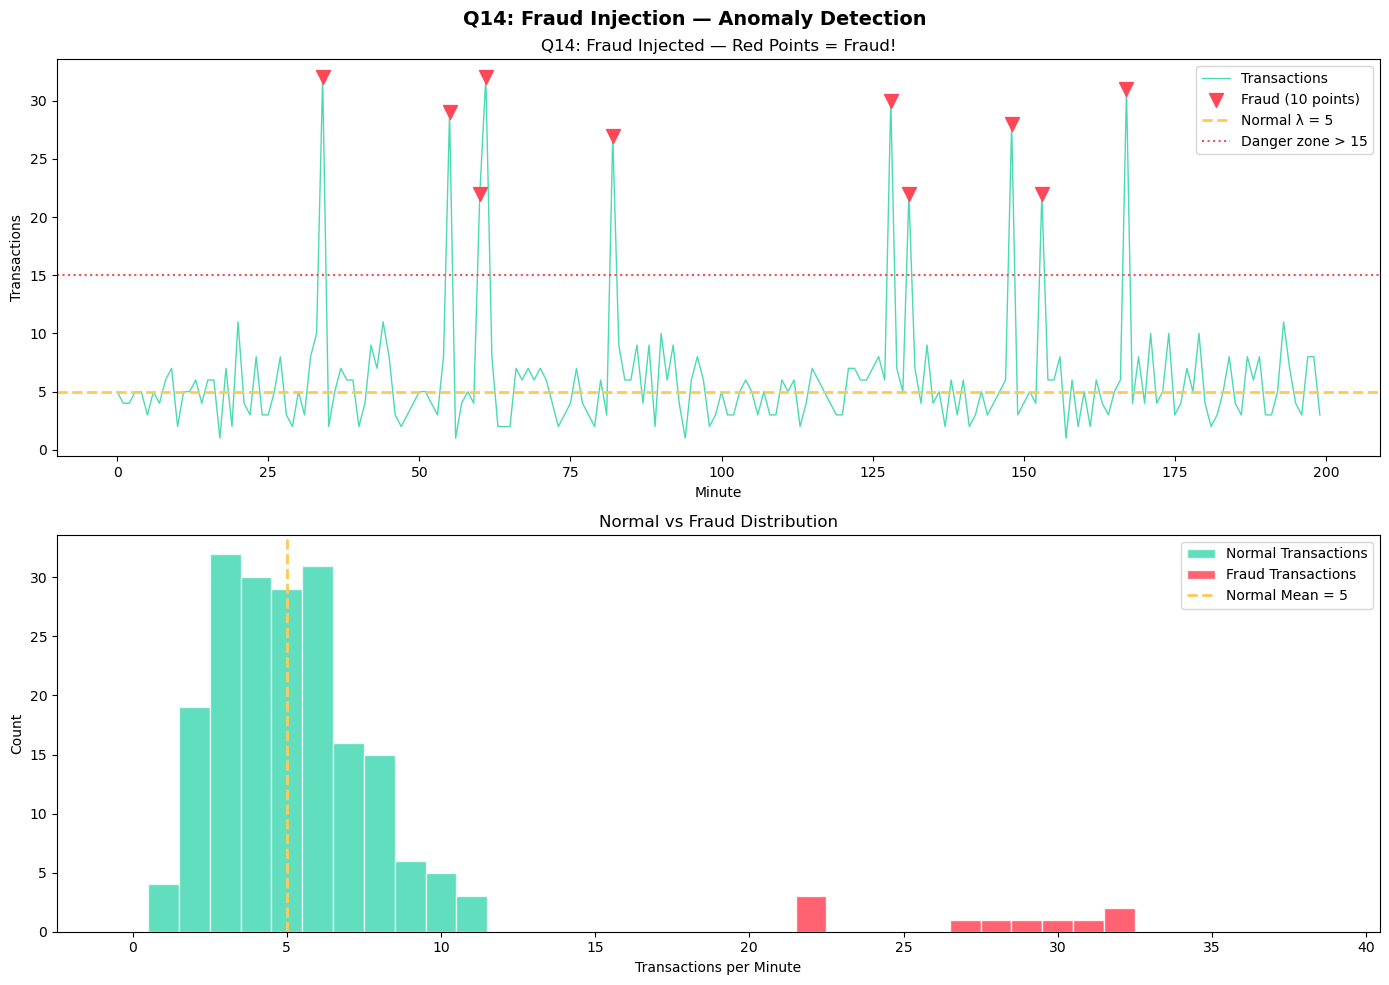

In [6]:



# Plot 
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Time Series with fraud points
axes[0].plot(df['Minute'],
             df['Transactions'],
             color='#1dd1a1',
             linewidth=1, alpha=0.8,
             label='Transactions')

# Fraud points in red color
axes[0].scatter(
    df[df['Is_Fraud']==1]['Minute'],
    df[df['Is_Fraud']==1]['Transactions'],
    color='#ff4757', s=100, zorder=5,
    label=f'Fraud ({n_frauds} points)',
    marker='v'
)

axes[0].axhline(lam,
                color='#feca57',
                linestyle='--', linewidth=2,
                label=f'Normal λ = {lam}')

# Danger zone
axes[0].axhline(lam * 3,
                color='#ff4757',
                linestyle=':', linewidth=1.5,
                label=f'Danger zone > {lam*3}')

axes[0].set_title('Q14: Fraud Injected — Red Points = Fraud!')
axes[0].set_xlabel('Minute')
axes[0].set_ylabel('Transactions')
axes[0].legend()

#  Normal vs Fraud distribution 
axes[1].hist(
    df[df['Is_Fraud']==0]['Transactions'],
    bins=range(0, 40),
    color='#1dd1a1', alpha=0.7,
    edgecolor='white',
    label='Normal Transactions',
    align='left'
)

axes[1].hist(
    df[df['Is_Fraud']==1]['Transactions'],
    bins=range(0, 40),
    color='#ff4757', alpha=0.85,
    edgecolor='white',
    label='Fraud Transactions',
    align='left'
)

axes[1].axvline(lam,
                color='#feca57',
                linestyle='--', linewidth=2,
                label=f'Normal Mean = {lam}')

axes[1].set_title('Normal vs Fraud Distribution')
axes[1].set_xlabel('Transactions per Minute')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Q14: Fraud Injection — Anomaly Detection',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🎛 Interactive Visualization (ipywidgets)

**Q17:** Create sliders for:
- Mean (μ)
- Standard deviation (σ)
- Lambda (λ)

Plot distributions dynamically.


In [ ]:
# Your code here


## 📊 Distribution Fitting

**Q18:** Given a dataset, fit Normal, Poisson, and Binomial distributions.

**Q19:** Use likelihood or visual comparison to decide best fit.


In [ ]:
# Your code here


## 🌍 Real Dataset Integration

**Q20:** Load real dataset (e.g., traffic, rainfall, or stock data).

**Q21:** Identify which distribution best models the data.

**Q22 (Challenge):** Build a small ML model using this dataset.


In [ ]:
# Your code here
